In [53]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import pickle

In [54]:
#loading the dataset
raw_mail_data = pd.read_csv(r"D:/personal projects/email spam filtering/mail_data.csv")

In [55]:
print(raw_mail_data)

     Category                                            Message
0         ham  Go until jurong point, crazy.. Available only ...
1         ham                      Ok lar... Joking wif u oni...
2        spam  Free entry in 2 a wkly comp to win FA Cup fina...
3         ham  U dun say so early hor... U c already then say...
4         ham  Nah I don't think he goes to usf, he lives aro...
...       ...                                                ...
5567     spam  This is the 2nd time we have tried 2 contact u...
5568      ham               Will ü b going to esplanade fr home?
5569      ham  Pity, * was in mood for that. So...any other s...
5570      ham  The guy did some bitching but I acted like i'd...
5571      ham                         Rofl. Its true to its name

[5572 rows x 2 columns]


In [56]:
# removing missing values
data = raw_mail_data.where((pd.notnull(raw_mail_data)),'')

In [57]:
# converting the labels (o=ham, 1=spam)
data['Category'] = data['Category'].map({'ham': 0, 'spam': 1})

In [58]:
data.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [59]:
data.shape

(5572, 2)

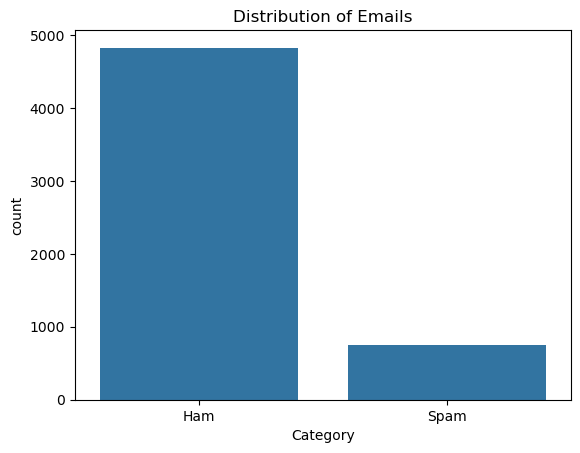

In [60]:
sns.countplot(x=data['Category'])
plt.xticks([0,1], ['Ham','Spam'])
plt.title("Distribution of Emails")
plt.show()

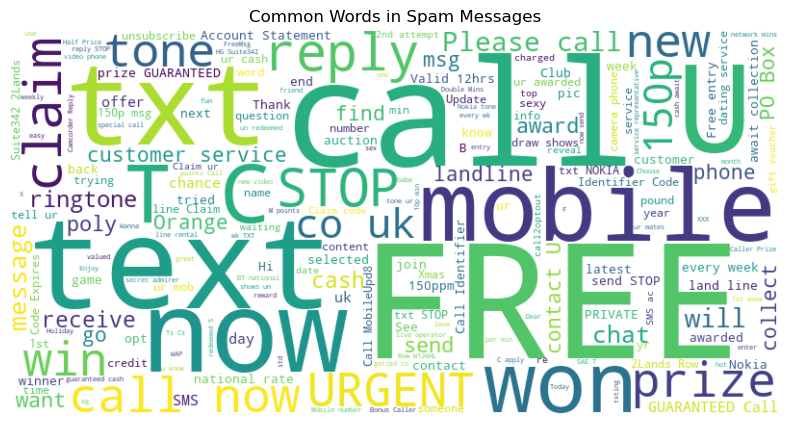

In [61]:
spam_words = " ".join(data[data['Category']==1]['Message'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(spam_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Common Words in Spam Messages")
plt.show()

In [62]:
X = data['Message']
y = data['Category']

In [63]:
# train-test split (80% & 20%) (stratified for balanced classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [64]:
print(X)

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                 Will ü b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: Message, Length: 5572, dtype: object


In [65]:
print(y)

0       0
1       0
2       1
3       0
4       0
       ..
5567    1
5568    0
5569    0
5570    0
5571    0
Name: Category, Length: 5572, dtype: int64


In [66]:
#logistic regression pipeline
logistic_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        min_df=1,
        stop_words='english',
        lowercase=True
    )),
    ('clf', LogisticRegression(max_iter=1000))
])

In [67]:
#naive bayes pipeline
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        min_df=1,
        stop_words='english',
        lowercase=True
    )),
    ('clf', MultinomialNB())
])

In [68]:
#training models
logistic_pipeline.fit(X_train, y_train)
nb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(stop_words='english')),
                ('clf', MultinomialNB())])

In [69]:
#evaluation of logistic regression model
logistic_pred = logistic_pipeline.predict(X_test)

print("=== Logistic Regression Results ===")
print("Accuracy:", accuracy_score(y_test, logistic_pred))
print("\nClassification Report:\n", classification_report(y_test, logistic_pred))

=== Logistic Regression Results ===
Accuracy: 0.9668161434977578

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.75      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



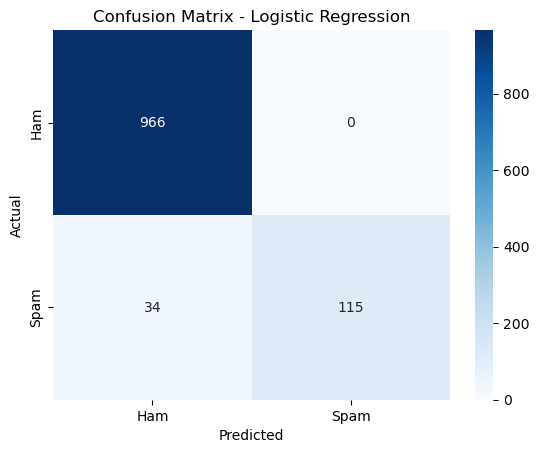

In [70]:
cm_l = confusion_matrix(y_test, nb_pred)

sns.heatmap(cm_l, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham','Spam'],
            yticklabels=['Ham','Spam'])

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [71]:
##evaluation of naive bayes model
nb_pred = nb_pipeline.predict(X_test)

print("=== Naive Bayes Results ===")
print("Accuracy:", accuracy_score(y_test, nb_pred))
print("\nClassification Report:\n", classification_report(y_test, nb_pred))

=== Naive Bayes Results ===
Accuracy: 0.9695067264573991

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



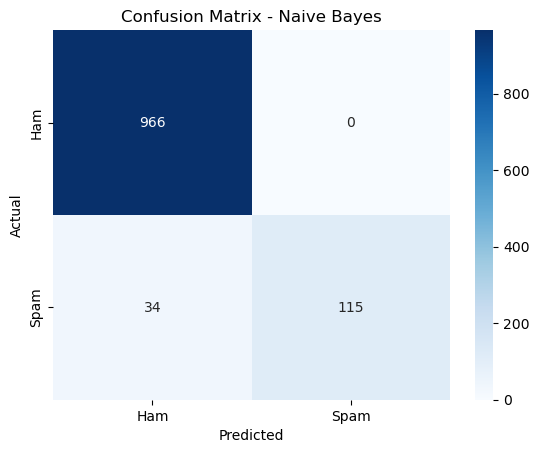

In [72]:
cm_n = confusion_matrix(y_test, nb_pred)

sns.heatmap(cm_n, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham','Spam'],
            yticklabels=['Ham','Spam'])

plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [73]:
#cross validation (5-fold)
logistic_cv = cross_val_score(logistic_pipeline, X, y, cv=5)
nb_cv = cross_val_score(nb_pipeline, X, y, cv=5)

print("Logistic Regression CV Mean:", logistic_cv.mean())
print("Naive Bayes CV Mean:", nb_cv.mean())

Logistic Regression CV Mean: 0.9639262223152538
Naive Bayes CV Mean: 0.9680537150493917


In [74]:
# select Naive Bayes as final model
final_model = nb_pipeline

In [75]:
final_model.fit(X, y)

Pipeline(steps=[('tfidf', TfidfVectorizer(stop_words='english')),
                ('clf', MultinomialNB())])

In [76]:
#saving the model using pickle
pickle.dump(final_model, open("spam_model.pkl", "wb"))

In [77]:
def predict_email(text):
    prediction = final_model.predict([text])[0]
    probability = final_model.predict_proba([text])[0][1]
    
    result = "Spam" if prediction == 1 else "Ham"
    
    return {
        "Prediction": result,
        "Spam Probability": round(probability, 4)
    }

In [78]:
sample_email_1 = "Congratulations! You've won a free iPhone. Click here now!"
sample_email_2 = "Hey, are we meeting tomorrow at 10?"

print(predict_email(sample_email_1))
print(predict_email(sample_email_2))

{'Prediction': 'Ham', 'Spam Probability': np.float64(0.4075)}
{'Prediction': 'Ham', 'Spam Probability': np.float64(0.01)}


In [79]:
print(final_model.predict_proba([sample_email_1]))

[[0.59249021 0.40750979]]


In [80]:
#changing the threshold for more accuracy
def predict_email(text, threshold=0.4):
    proba = float(final_model.predict_proba([text])[0][1])
    prediction = 1 if proba >= threshold else 0
    
    label = "Spam" if prediction == 1 else "Ham"
    return label, round(proba, 4)

In [81]:
print(predict_email(sample_email_1, threshold=0.4))

('Spam', 0.4075)


In [82]:
sample_email_1 = "Congratulations! You've won a free iPhone. Click here now!"
sample_email_2 = "Hey, are we meeting tomorrow at 10?"

print(predict_email(sample_email_1))
print(predict_email(sample_email_2))

('Spam', 0.4075)
('Ham', 0.01)
